# Project — Customer Segmentation using RFM Analysis
### Data Cleaning, RFM Scoring & Segmentation Notebook (Python)

This notebook covers every task from the brief:
1. Clean and prepare transactional customer data
2. Calculate RFM metrics (Recency, Frequency, Monetary)
3. Segment customers into groups (loyal, churn risk, new, etc.)
4. Analyze behavior patterns of each segment
5. Provide targeted marketing recommendations
6. Visualize segments using charts


## 1. Import Libraries & Load Raw Transaction Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("D:Projects/Jupyter_python/Customer_Segmentation_using_RFM_Analysis/raw_transactions.csv", parse_dates=["InvoiceDate"])
print("Shape:", df.shape)
df.head()


Shape: (13572, 8)


,InvoiceNo,InvoiceDate,CustomerID,Country,ProductID,ProductDescription,Quantity,UnitPrice
0,INV378786,2024-10-18,CUST0115,USA,P1009,Backpack,1,43.63
1,INV689706,2024-05-24,CUST0346,Canada,P1011,Table Lamp,3,26.53
2,INV685450,2024-12-15,CUST0153,India,P1012,Gaming Headset,1,55.27
3,INV819141,2023-01-02,CUST0021,Brazil,P1015,Winter Jacket,4,119.90
4,INV995110,2024-06-07,CUST0675,Canada,P1011,Table Lamp,3,28.76


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13572 entries, 0 to 13571
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   InvoiceNo           13572 non-null  str           
 1   InvoiceDate         13572 non-null  datetime64[us]
 2   CustomerID          13165 non-null  str           
 3   Country             13572 non-null  str           
 4   ProductID           13572 non-null  str           
 5   ProductDescription  13572 non-null  str           
 6   Quantity            13572 non-null  int64         
 7   UnitPrice           13436 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 1.3 MB


In [3]:
# Check nulls and duplicates
print("Nulls per column:\n", df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())

Nulls per column:
 InvoiceNo               0
InvoiceDate             0
CustomerID            407
Country                 0
ProductID               0
ProductDescription      0
Quantity                0
UnitPrice             136
dtype: int64

Exact duplicate rows: 224


### 1.1 Data Cleaning

RFM analysis needs, per transaction: a valid **CustomerID**, a valid **InvoiceDate**, and a valid, positive **Quantity × UnitPrice**. Steps:

- Remove exact duplicate rows
- Drop rows with missing CustomerID (guest checkouts can't be tied to a customer, so they're unusable for RFM)
- Remove cancelled/returned orders (InvoiceNo starting with "C", or negative/zero Quantity) — these aren't genuine purchases
- Drop rows with missing or invalid UnitPrice
- Standardize text columns (Country)
- Compute `TotalAmount = Quantity * UnitPrice` per line item


In [4]:
# Remove exact duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 224 duplicate rows


In [5]:
# Drop rows with missing CustomerID (can't attribute to a customer)
before = len(df)
df = df.dropna(subset=["CustomerID"])
print(f"Removed {before - len(df)} rows with missing CustomerID")

Removed 406 rows with missing CustomerID


In [6]:
# Remove cancelled/returned transactions
before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
print(f"Removed {before - len(df)} cancelled/invalid-quantity rows")

Removed 437 cancelled/invalid-quantity rows


In [7]:
# Drop rows with missing or non-positive UnitPrice
before = len(df)
df = df.dropna(subset=["UnitPrice"])
df = df[df["UnitPrice"] > 0]
print(f"Removed {before - len(df)} rows with missing/invalid UnitPrice")

Removed 127 rows with missing/invalid UnitPrice


In [8]:
# Standardize text columns
df["Country"] = df["Country"].astype(str).str.strip().str.title()
df["CustomerID"] = df["CustomerID"].astype(str).str.strip()

df["Country"].value_counts()

Country
France       1879
Germany      1754
Australia    1613
Canada       1531
India        1527
Brazil       1410
Usa          1363
Uk           1301
Name: count, dtype: int64

In [9]:
# Compute per-line-item revenue
df["TotalAmount"] = (df["Quantity"] * df["UnitPrice"]).round(2)

print("Final cleaned shape:", df.shape)
print("Unique customers:", df["CustomerID"].nunique())
print("Date range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())
df.head()

Final cleaned shape: (12378, 9)
Unique customers: 798
Date range: 2023-01-01 00:00:00 to 2024-12-30 00:00:00


,InvoiceNo,InvoiceDate,CustomerID,Country,ProductID,ProductDescription,Quantity,UnitPrice,TotalAmount
0,INV378786,2024-10-18,CUST0115,Usa,P1009,Backpack,1,43.63,43.63
1,INV689706,2024-05-24,CUST0346,Canada,P1011,Table Lamp,3,26.53,79.59
2,INV685450,2024-12-15,CUST0153,India,P1012,Gaming Headset,1,55.27,55.27
3,INV819141,2023-01-02,CUST0021,Brazil,P1015,Winter Jacket,4,119.90,479.60
4,INV995110,2024-06-07,CUST0675,Canada,P1011,Table Lamp,3,28.76,86.28


## 2. Calculate RFM Metrics

- **Recency (R):** days since the customer's most recent purchase, measured from a fixed "snapshot date" (one day after the last date in the dataset)
- **Frequency (F):** number of distinct invoices (orders) the customer has placed
- **Monetary (M):** total amount the customer has spent


In [11]:
snapshot_date = df["InvoiceDate"].max() + timedelta(days=1)
print("Snapshot date:", snapshot_date.date())

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

rfm["Monetary"] = rfm["Monetary"].round(2)
rfm.head()

Snapshot date: 2024-12-31


,CustomerID,Recency,Frequency,Monetary
0,CUST0001,15,24,5424.77
1,CUST0002,19,2,171.31
2,CUST0003,430,2,494.61
3,CUST0004,4,24,7104.64
4,CUST0005,21,11,3134.42


In [12]:
rfm.describe()

,Recency,Frequency,Monetary
count,798.000000,798.000000,798.000000
mean,115.796992,6.406015,1675.330439
std,130.600318,5.697569,1616.944913
min,1.000000,1.000000,4.060000
25%,18.000000,2.000000,532.230000
50%,68.500000,4.500000,1155.725000
75%,145.000000,9.000000,2358.427500
max,499.000000,29.000000,9443.900000


## 3. Score RFM & Segment Customers

Each metric is split into 5 quantile-based bins (score 1–5). For Recency, a **lower** number of days is better, so the scoring is reversed (most recent = score 5). For Frequency and Monetary, higher is better (score 5 = most frequent/highest spend).

The three scores are combined into an `RFM_Score` and then mapped to human-readable segments using standard RFM segment rules.

In [13]:
# Recency: lower is better -> reverse labels so recent = 5
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency & Monetary: higher is better. rank(method="first") avoids errors from duplicate bin edges
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Sum"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum
0,CUST0001,15,24,5424.77,5,5,5,555,15
1,CUST0002,19,2,171.31,4,1,1,411,6
2,CUST0003,430,2,494.61,1,1,2,112,4
3,CUST0004,4,24,7104.64,5,5,5,555,15
4,CUST0005,21,11,3134.42,4,5,5,455,14


In [14]:
def segment_customer(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r >= 3 and f <= 2 and m <= 2:
        return "Promising"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r <= 2 and f >= 4 and m >= 4:
        return "Cant Lose Them"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    else:
        return "Needs Attention"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)
rfm["Segment"].value_counts()

Segment
Champions          171
At Risk            158
New Customers      140
Needs Attention    107
Loyal Customers     93
Lost                89
Promising           40
Name: count, dtype: int64

## 4. Analyze Behavior Patterns of Each Segment

In [15]:
segment_profile = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Monetary=("Monetary", "sum")
).round(1).sort_values("Total_Monetary", ascending=False)

segment_profile["Pct_of_Customers"] = (segment_profile["Customers"] / segment_profile["Customers"].sum() * 100).round(1)
segment_profile["Pct_of_Revenue"] = (segment_profile["Total_Monetary"] / segment_profile["Total_Monetary"].sum() * 100).round(1)

segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Pct_of_Customers,Pct_of_Revenue
Segment,,,,,,,
Champions,171,16.2,14.8,3906.4,667990.9,21.4,50.0
At Risk,158,194.5,6.5,1816.8,287051.6,19.8,21.5
Loyal Customers,93,67.0,6.8,1896.9,176409.4,11.7,13.2
Needs Attention,107,216.6,3.7,883.6,94547.6,13.4,7.1
New Customers,140,15.4,1.5,356.6,49918.2,17.5,3.7
Lost,89,276.5,2.4,480.5,42768.5,11.2,3.2
Promising,40,68.6,2.4,455.7,18227.4,5.0,1.4


## 5. Visualize Segments

C:\Users\Dell\AppData\Local\Temp\ipykernel_150156\16891116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_order, y=segment_profile["Customers"], palette="viridis")


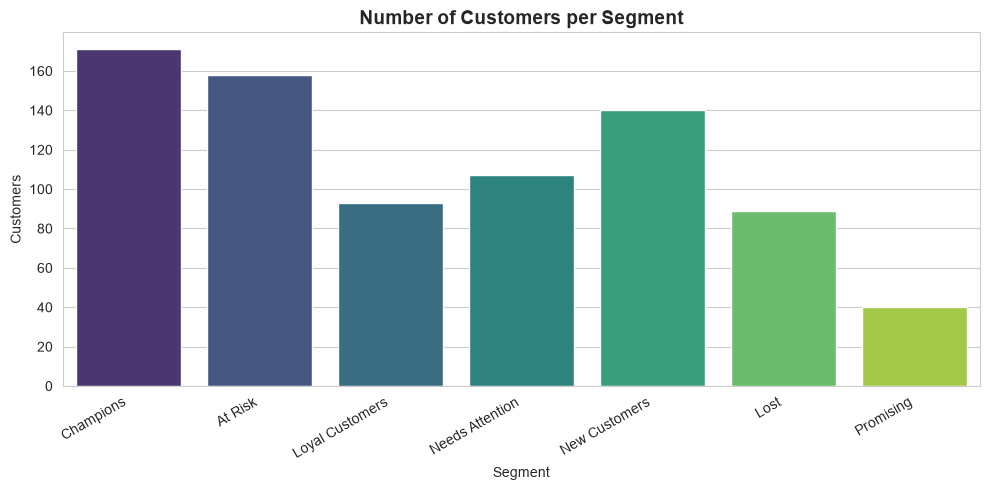

In [16]:
# Segment size -- BAR CHART
plt.figure(figsize=(10, 5))
seg_order = segment_profile.index
sns.barplot(x=seg_order, y=segment_profile["Customers"], palette="viridis")
plt.title("Number of Customers per Segment", fontsize=14, fontweight="bold")
plt.ylabel("Customers")
plt.xlabel("Segment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("segment_customer_count_bar.png", dpi=150)
plt.show()

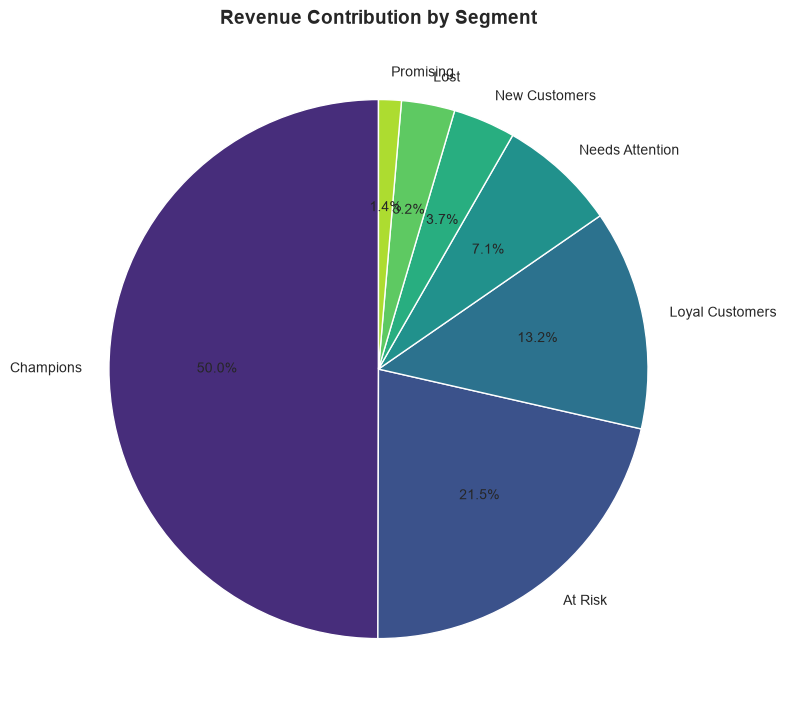

In [17]:
# Revenue contribution by segment -- PIE CHART
plt.figure(figsize=(8, 8))
plt.pie(segment_profile["Total_Monetary"], labels=segment_profile.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("viridis", len(segment_profile)))
plt.title("Revenue Contribution by Segment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("segment_revenue_pie.png", dpi=150)
plt.show()

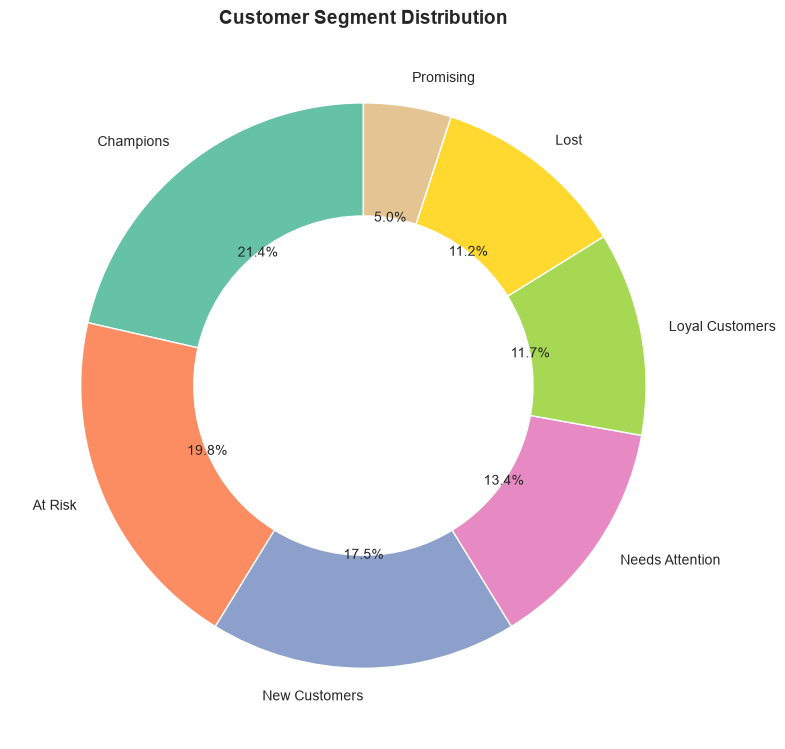

In [18]:
# Segment distribution -- DONUT/PIE by customer count
plt.figure(figsize=(8, 8))
colors = sns.color_palette("Set2", len(rfm["Segment"].value_counts()))
plt.pie(rfm["Segment"].value_counts(), labels=rfm["Segment"].value_counts().index,
        autopct="%1.1f%%", startangle=90, colors=colors,
        wedgeprops={"width": 0.4})
plt.title("Customer Segment Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("segment_distribution_donut.png", dpi=150)
plt.show()

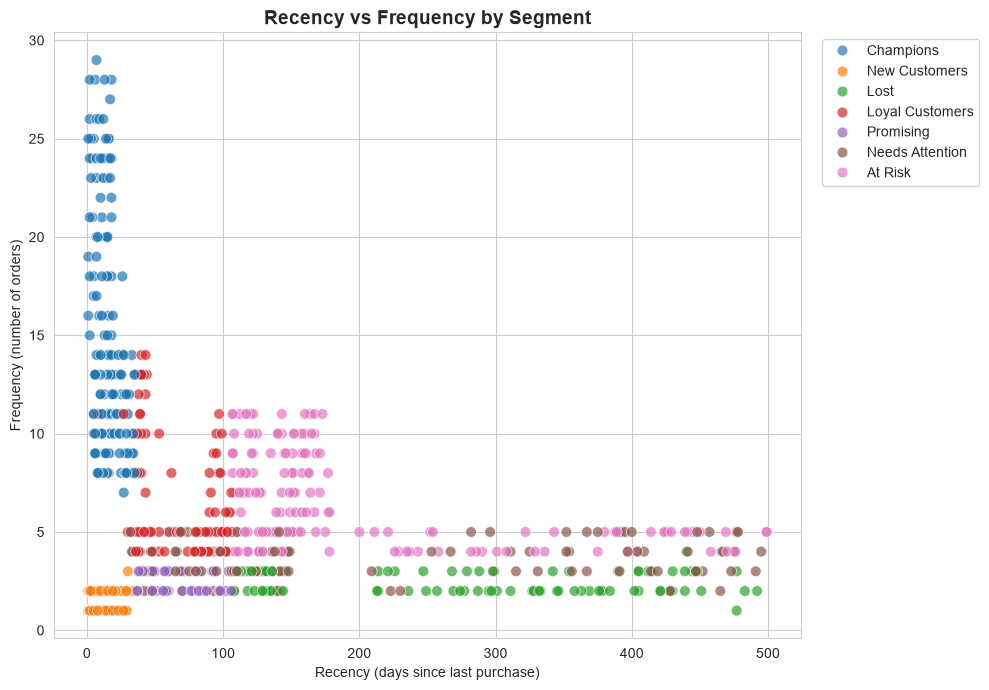

In [19]:
# Recency vs Frequency scatter, colored by segment
plt.figure(figsize=(10, 7))
sns.scatterplot(data=rfm, x="Recency", y="Frequency", hue="Segment", palette="tab10", alpha=0.7, s=60)
plt.title("Recency vs Frequency by Segment", fontsize=14, fontweight="bold")
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Frequency (number of orders)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("recency_vs_frequency_scatter.png", dpi=150)
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_150156\3337034274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_profile.index, y=segment_profile["Avg_Monetary"], palette="magma")


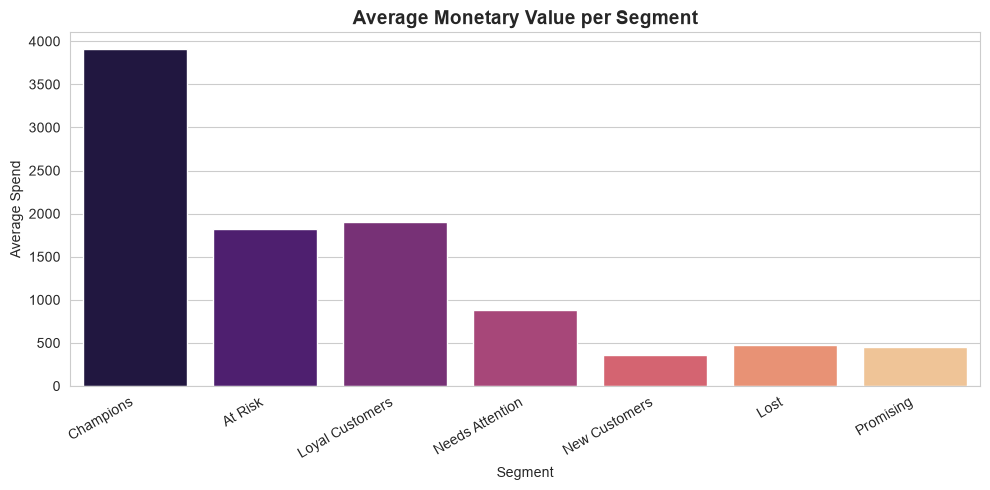

In [20]:
# Average Monetary value per segment -- BAR CHART
plt.figure(figsize=(10, 5))
sns.barplot(x=segment_profile.index, y=segment_profile["Avg_Monetary"], palette="magma")
plt.title("Average Monetary Value per Segment", fontsize=14, fontweight="bold")
plt.ylabel("Average Spend")
plt.xlabel("Segment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("segment_avg_monetary_bar.png", dpi=150)
plt.show()

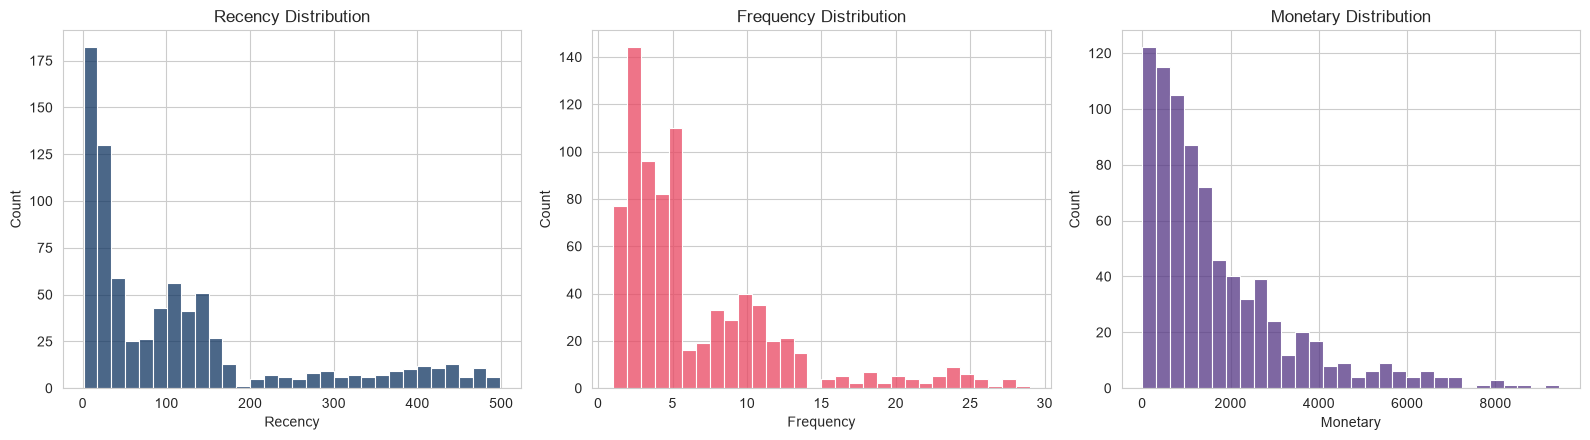

In [21]:
# RFM metric distributions -- HISTOGRAMS
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(rfm["Recency"], bins=30, color="#0f3460", ax=axes[0])
axes[0].set_title("Recency Distribution")
sns.histplot(rfm["Frequency"], bins=30, color="#e94560", ax=axes[1])
axes[1].set_title("Frequency Distribution")
sns.histplot(rfm["Monetary"], bins=30, color="#533483", ax=axes[2])
axes[2].set_title("Monetary Distribution")
plt.tight_layout()
plt.savefig("rfm_distributions_hist.png", dpi=150)
plt.show()

## 6. Targeted Marketing Recommendations

Based on the standard RFM segment definitions, here are recommended actions per segment (edit wording based on your actual segment_profile numbers above):



| Segment | Who they are | Recommended action |
|---|---|---|
| **Champions** | Bought recently, buy often, spend the most | Reward with early access to new products, loyalty perks, VIP treatment — protect this segment, they drive disproportionate revenue |
| **Loyal Customers** | Buy regularly, solid spend | Upsell higher-value products, enroll in a loyalty program, ask for reviews/referrals |
| **New Customers** | Recent first-time buyers, low frequency so far | Onboarding email series, first-repeat-purchase discount, build habit before they drift away |
| **Promising** | Recent but low spend/frequency so far | Targeted product recommendations based on their first purchase, small incentive for a second order |
| **Needs Attention** | Average recency/frequency/monetary, could go either way | Personalized re-engagement campaign, limited-time offer to nudge them toward "Loyal" |
| **At Risk** | Used to buy often/well but haven't returned recently | Win-back email campaign, personalized discount, ask for feedback on why they stopped |
| **Cant Lose Them** | High past frequency/spend but very inactive recently | High-priority win-back outreach (e.g. personal contact, exclusive offer) — high value at risk of full churn |
| **Lost** | Low recency, frequency, and monetary across the board | Low-cost reactivation campaign (broad discount); if unresponsive, deprioritize marketing spend here |


## 7. Export RFM Table for Power BI / Further Use

In [22]:
rfm_export = rfm.merge(
    df.groupby("CustomerID")["Country"].agg(lambda x: x.mode()[0]).reset_index(),
    on="CustomerID", how="left"
)

rfm_export.to_csv("customer_rfm_segments.csv", index=False)
df.to_csv("cleaned_transactions.csv", index=False)

print("Exported: customer_rfm_segments.csv, cleaned_transactions.csv")
print("RFM table shape:", rfm_export.shape)
rfm_export.head()


Exported: customer_rfm_segments.csv, cleaned_transactions.csv
RFM table shape: (798, 11)


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum,Segment,Country
0,CUST0001,15,24,5424.77,5,5,5,555,15,Champions,Germany
1,CUST0002,19,2,171.31,4,1,1,411,6,New Customers,Australia
2,CUST0003,430,2,494.61,1,1,2,112,4,Lost,Australia
3,CUST0004,4,24,7104.64,5,5,5,555,15,Champions,India
4,CUST0005,21,11,3134.42,4,5,5,455,14,Champions,Brazil
